In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from collections import Counter

import medmnist
from medmnist import INFO, Evaluator
from medmnist import DermaMNIST

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader
from torch.utils.data import WeightedRandomSampler
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models import efficientnet_b1, EfficientNet_B1_Weights
from medmnist import DermaMNIST

# from pytorch_grad_cam import GradCAM
# from pytorch_grad_cam.utils.image import show_cam_on_image
# from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [2]:
data_set = "dermamnist"
download = True

info = INFO[data_set]
task = info["task"] 
n_channels = info["n_channels"]
n_classes = len(info["label"])  
print(f"Task: {task}, Channels: {n_channels}, Number of classes: {n_classes}")

# change sizes here for different resolutions
train_dataset = DermaMNIST(split="train", download=False, size=224)
val_dataset = DermaMNIST(split="val", download=False, size=224)
test_dataset = DermaMNIST(split="test", download=False, size=224)

print(f"Number of training images: {len(train_dataset)}")
print(f"Number of validation images: {len(val_dataset)}")
print(f"Number of test images: {len(test_dataset)}")

Task: multi-class, Channels: 3, Number of classes: 7
Number of training images: 7007
Number of validation images: 1003
Number of test images: 2005


In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


In [4]:
class_names = [info["label"][str(i)] for i in range(n_classes)]
datasets = [train_dataset, val_dataset, test_dataset]
dataset_names = ["train", "validation", "test"]

total_counter = Counter()
split_counters = {}

for i in range(3):
    count_labels = [int(label[0]) for _, label in datasets[i]]
    class_counts = Counter(count_labels)
    
    split_name = dataset_names[i]
    split_counters[split_name] = class_counts
    
    total_counter += class_counts

    print(f"[{split_name}] number of images per class:")
    print("-----")
    for j in range(n_classes):   
        count = class_counts[j]
        print(f"{class_names[j]}: {count}")
    print("-----")

total_images = sum(total_counter.values())
print("[total] number and proportions of images per class:")
print("-----")
for j in range(n_classes):
    count = total_counter[j]
    proportion = count / total_images
    print(f"{class_names[j]}: {count} ({proportion:.2%})")
print("-----")

rows = []
for j in range(n_classes):
    row = {
        "class": class_names[j],
        "train": split_counters["train"][j],
        "validation": split_counters["validation"][j],
        "test": split_counters["test"][j],
        "total": total_counter[j],
        "proportion": total_counter[j] / total_images
    }
    rows.append(row)

df = pd.DataFrame(rows)
df

[train] number of images per class:
-----
actinic keratoses and intraepithelial carcinoma: 228
basal cell carcinoma: 359
benign keratosis-like lesions: 769
dermatofibroma: 80
melanoma: 779
melanocytic nevi: 4693
vascular lesions: 99
-----
[validation] number of images per class:
-----
actinic keratoses and intraepithelial carcinoma: 33
basal cell carcinoma: 52
benign keratosis-like lesions: 110
dermatofibroma: 12
melanoma: 111
melanocytic nevi: 671
vascular lesions: 14
-----
[test] number of images per class:
-----
actinic keratoses and intraepithelial carcinoma: 66
basal cell carcinoma: 103
benign keratosis-like lesions: 220
dermatofibroma: 23
melanoma: 223
melanocytic nevi: 1341
vascular lesions: 29
-----
[total] number and proportions of images per class:
-----
actinic keratoses and intraepithelial carcinoma: 327 (3.27%)
basal cell carcinoma: 514 (5.13%)
benign keratosis-like lesions: 1099 (10.97%)
dermatofibroma: 115 (1.15%)
melanoma: 1113 (11.11%)
melanocytic nevi: 6705 (66.95%)
v

,class,train,validation,test,total,proportion
0,actinic keratoses and intraepithelial carcinoma,228,33,66,327,0.032651
1,basal cell carcinoma,359,52,103,514,0.051323
2,benign keratosis-like lesions,769,110,220,1099,0.109735
3,dermatofibroma,80,12,23,115,0.011483
4,melanoma,779,111,223,1113,0.111133
5,melanocytic nevi,4693,671,1341,6705,0.669496
6,vascular lesions,99,14,29,142,0.014179


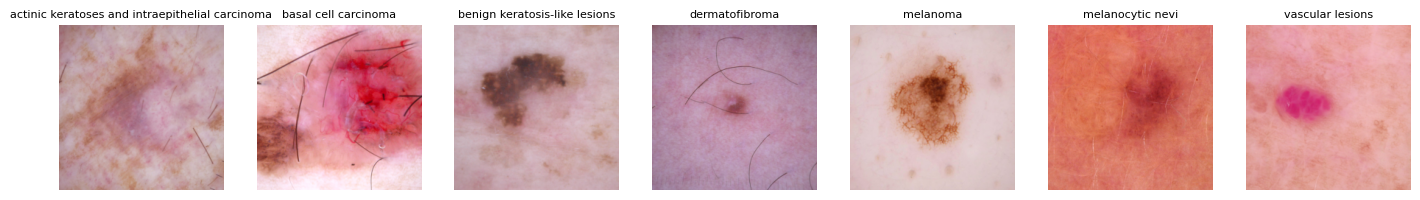

In [5]:
def show_one_per_class(dataset, class_names):
    n_classes = len(class_names)
    fig, axes = plt.subplots(1, n_classes, figsize=(2*n_classes, 2))

    if n_classes == 1:
        axes = [axes]
    
    shown_classes = set()
    for img, label in dataset:
        class_idx = int(label[0])
        
        if class_idx not in shown_classes:
            ax = axes[class_idx]
            
            if hasattr(img, "numpy"): 
                img_np = img.permute(1, 2, 0).numpy()
            else:  
                img_np = np.array(img)
            
            ax.imshow(img_np)
            ax.set_title(class_names[class_idx], fontsize=8)
            ax.axis("off")
            shown_classes.add(class_idx)
        
        if len(shown_classes) == n_classes:
            break

    plt.tight_layout()
    plt.show()

show_one_per_class(train_dataset, class_names)

In [6]:
# data imbalanced, nevi dominate with small counts for other classes
# benign classes: nevi, benign keratosis, dermatofibroma, vascular lesions
# malignant classes: melanoma, basal cell carcinoma
# pre-malignant / early stage: actinic keratoses and intraepithelial carcinoma

In [7]:
img, label = train_dataset[0]
print(np.array(img).shape)
info["n_channels"]

(224, 224, 3)


3

In [8]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

In [9]:
train_dataset = DermaMNIST(
    split="train",
    transform=train_transform,   
    download=True,
    size=224
)

val_dataset = DermaMNIST(
    split="val",
    transform=test_transform,
    download=True,
    size=224
)

test_dataset = DermaMNIST(
    split="test",
    transform=test_transform,
    download=True,
    size=224
)

In [10]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4)

n_classes = len(train_dataset.info["label"])

In [11]:
def get_efficientnet_b0():
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, n_classes)
    return model.to(device)

def get_efficientnet_b1():
    model = efficientnet_b1(weights=EfficientNet_B1_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, n_classes)
    return model.to(device)

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

def compute_auc(model, loader, split):
    model.eval()
    
    y_true = []
    y_score = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            y_true.append(labels.cpu())
            y_score.append(probs.cpu())

    y_true = torch.cat(y_true).numpy()
    y_score = torch.cat(y_score).numpy()

    evaluator = Evaluator("dermamnist", split)
    metrics = evaluator.evaluate(y_score)

    return metrics

In [12]:
train_labels = [int(label[0]) for _, label in train_dataset]
class_counts = np.bincount(train_labels)

print("Class counts:", class_counts)

class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
class_weights = class_weights / class_weights.sum() * len(class_counts)

print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

Class counts: [ 228  359  769   80  779 4693   99]
Class weights: tensor([0.9426, 0.5987, 0.2795, 2.6865, 0.2759, 0.0458, 2.1709])


In [13]:
def train_model(model, train_loader, val_loader, epochs=5, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr)

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        val_acc = evaluate(model, val_loader)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss:.4f} | Val Acc: {val_acc:.4f}")

    return model

In [14]:
effnet_b0 = get_efficientnet_b0()
effnet_b0 = train_model(effnet_b0, train_loader, val_loader, epochs=10)

test_acc_b0 = evaluate(effnet_b0, test_loader)

print(f"EfficientNet-b0 Test Accuracy: {test_acc_b0:.4f}")

val_auc_b0 = compute_auc(effnet_b0, val_loader, split="val")
test_auc_b0 = compute_auc(effnet_b0, test_loader, split="test")

print("EfficientNet-b0 Val Metrics:", val_auc_b0)
print("EfficientNet-b0 Test Metrics:", test_auc_b0)

Epoch 1/10 | Loss: 132.2480 | Val Acc: 0.5892
Epoch 2/10 | Loss: 101.8043 | Val Acc: 0.5513
Epoch 3/10 | Loss: 81.3287 | Val Acc: 0.6012
Epoch 4/10 | Loss: 73.5782 | Val Acc: 0.7527
Epoch 5/10 | Loss: 67.2397 | Val Acc: 0.7159
Epoch 6/10 | Loss: 64.0659 | Val Acc: 0.7866
Epoch 7/10 | Loss: 54.4032 | Val Acc: 0.7388
Epoch 8/10 | Loss: 46.1384 | Val Acc: 0.7787
Epoch 9/10 | Loss: 45.2104 | Val Acc: 0.6979
Epoch 10/10 | Loss: 41.8165 | Val Acc: 0.7836
EfficientNet-b0 Test Accuracy: 0.7890
EfficientNet-b0 Val Metrics: Metrics(AUC=0.9603389044060916, ACC=0.7836490528414756)
EfficientNet-b0 Test Metrics: Metrics(AUC=0.9684184561738695, ACC=0.7890274314214464)


In [15]:
effnet_b1 = get_efficientnet_b1()
effnet_b1 = train_model(effnet_b1, train_loader, val_loader, epochs=10)

test_acc_b1 = evaluate(effnet_b1, test_loader)

print(f"EfficientNet-b1 Test Accuracy: {test_acc_b1:.4f}")

val_auc_b1 = compute_auc(effnet_b1, val_loader, split="val")
test_auc_b1 = compute_auc(effnet_b1, test_loader, split="test")

print("EfficientNet-b1 Val Metrics:", val_auc_b1)
print("EfficientNet-b1 Test Metrics:", test_auc_b1)

Epoch 1/10 | Loss: 125.5707 | Val Acc: 0.6969
Epoch 2/10 | Loss: 85.3998 | Val Acc: 0.7009
Epoch 3/10 | Loss: 64.0537 | Val Acc: 0.7388
Epoch 4/10 | Loss: 60.1109 | Val Acc: 0.7328
Epoch 5/10 | Loss: 47.2097 | Val Acc: 0.7557
Epoch 6/10 | Loss: 46.8967 | Val Acc: 0.7667
Epoch 7/10 | Loss: 38.8028 | Val Acc: 0.7557
Epoch 8/10 | Loss: 32.8022 | Val Acc: 0.7767
Epoch 9/10 | Loss: 27.2961 | Val Acc: 0.7657
Epoch 10/10 | Loss: 28.5985 | Val Acc: 0.7817
EfficientNet-b1 Test Accuracy: 0.7915
EfficientNet-b1 Val Metrics: Metrics(AUC=0.9755956990166992, ACC=0.7816550348953141)
EfficientNet-b1 Test Metrics: Metrics(AUC=0.9734999731844258, ACC=0.7915211970074812)


In [16]:
# https://github.com/Peachypie98/CBAM
import torch.nn.functional as F

class CAM(nn.Module):
    def __init__(self, channels, r=16):
        super().__init__()

        self.linear = nn.Sequential(
            nn.Linear(channels, channels // r),
            nn.ReLU(inplace=True),
            nn.Linear(channels // r, channels)
        )

    def forward(self, x):
        max_pool = F.adaptive_max_pool2d(x, 1)
        avg_pool = F.adaptive_avg_pool2d(x, 1)

        b, c, _, _ = x.size()

        max_out = self.linear(max_pool.view(b, c)).view(b, c, 1, 1)
        avg_out = self.linear(avg_pool.view(b, c)).view(b, c, 1, 1)

        attention = torch.sigmoid(max_out + avg_out)
        return attention * x


class SAM(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)

    def forward(self, x):
        max_pool = torch.max(x, dim=1, keepdim=True)[0]
        avg_pool = torch.mean(x, dim=1, keepdim=True)

        concat = torch.cat([max_pool, avg_pool], dim=1)
        attention = torch.sigmoid(self.conv(concat))

        return attention * x


class CBAM(nn.Module):
    def __init__(self, channels, r=16):
        super().__init__()
        self.cam = CAM(channels, r)
        self.sam = SAM()

    def forward(self, x):
        out = self.cam(x)
        out = self.sam(out)
        return out + x

In [17]:
class EfficientNet_CBAM(nn.Module):
    def __init__(self, model_name, n_classes):
        super().__init__()

        if model_name == "efficientnet_b0":
            self.backbone = models.efficientnet_b0(pretrained=True)
        elif model_name == "efficientnet_b1":
            self.backbone = models.efficientnet_b1(pretrained=True)

        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        self.attention = CBAM(num_features)
        self.classifier = nn.Linear(num_features, n_classes)

    def forward(self, x):
        x = self.backbone.features(x)

        x = self.attention(x)

        x = self.backbone.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [18]:
efficientnet_b0_cbam = EfficientNet_CBAM("efficientnet_b0", n_classes).to(device)
efficientnet_b0_cbam = train_model(efficientnet_b0_cbam, train_loader, val_loader, epochs=5)

test_acc_b0_cbam = evaluate(efficientnet_b0_cbam, test_loader)
print(f"EfficientNet-B0 Test Accuracy: {test_acc_b0_cbam:.4f}")

val_auc_b0_cbam = compute_auc(efficientnet_b0_cbam, val_loader, split="val")
test_auc_b0_cbam = compute_auc(efficientnet_b0_cbam, test_loader, split="test")

print("EfficientNet-B0 Val Metrics:", val_auc_b0_cbam)
print("EfficientNet-B0 Test Metrics:", test_auc_b0_cbam)

/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/5 | Loss: 138.6276 | Val Acc: 0.6830
Epoch 2/5 | Loss: 100.5490 | Val Acc: 0.6431
Epoch 3/5 | Loss: 84.3762 | Val Acc: 0.6770
Epoch 4/5 | Loss: 76.0341 | Val Acc: 0.7408
Epoch 5/5 | Loss: 68.4641 | Val Acc: 0.6959
EfficientNet-B0 Test Accuracy: 0.7062
EfficientNet-B0 Val Metrics: Metrics(AUC=0.9555703432795591, ACC=0.6959122632103689)
EfficientNet-B0 Test Metrics: Metrics(AUC=0.9552205614736338, ACC=0.7062344139650872)


In [19]:
efficientnet_b0_cbam = EfficientNet_CBAM("efficientnet_b0", n_classes).to(device)
efficientnet_b0_cbam = train_model(efficientnet_b0_cbam, train_loader, val_loader, epochs=5, lr=1e-4)

test_acc_b0_cbam = evaluate(efficientnet_b0_cbam, test_loader)
print(f"EfficientNet-B0 Test Accuracy: {test_acc_b0_cbam:.4f}")

val_auc_b0_cbam = compute_auc(efficientnet_b0_cbam, val_loader, split="val")
test_auc_b0_cbam = compute_auc(efficientnet_b0_cbam, test_loader, split="test")

print("EfficientNet-B0 Val Metrics:", val_auc_b0_cbam)
print("EfficientNet-B0 Test Metrics:", test_auc_b0_cbam)

/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/5 | Loss: 161.4475 | Val Acc: 0.5962
Epoch 2/5 | Loss: 87.6909 | Val Acc: 0.7119
Epoch 3/5 | Loss: 66.7018 | Val Acc: 0.7258
Epoch 4/5 | Loss: 52.9671 | Val Acc: 0.7318
Epoch 5/5 | Loss: 43.9752 | Val Acc: 0.7777
EfficientNet-B0 Test Accuracy: 0.7711
EfficientNet-B0 Val Metrics: Metrics(AUC=0.9654692127887189, ACC=0.7776669990029911)
EfficientNet-B0 Test Metrics: Metrics(AUC=0.9627526253750779, ACC=0.771072319201995)


In [20]:
efficientnet_b1_cbam = EfficientNet_CBAM("efficientnet_b1", n_classes).to(device)
efficientnet_b1_cbam = train_model(efficientnet_b1_cbam, train_loader, val_loader, epochs=5)

test_acc_b1_cbam = evaluate(efficientnet_b1_cbam, test_loader)
print(f"EfficientNet-B1 Test Accuracy: {test_acc_b1_cbam:.4f}")

val_auc_b1_cbam = compute_auc(efficientnet_b1_cbam, val_loader, split="val")
test_auc_b1_cbam = compute_auc(efficientnet_b1_cbam, test_loader, split="test")

print("EfficientNet-B1 Val Metrics:", val_auc_b1_cbam)
print("EfficientNet-B1 Test Metrics:", test_auc_b1_cbam)

/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B1_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/5 | Loss: 123.7642 | Val Acc: 0.5813
Epoch 2/5 | Loss: 85.5663 | Val Acc: 0.6939
Epoch 3/5 | Loss: 74.0118 | Val Acc: 0.7577
Epoch 4/5 | Loss: 62.8692 | Val Acc: 0.7029
Epoch 5/5 | Loss: 53.3726 | Val Acc: 0.7478
EfficientNet-B1 Test Accuracy: 0.7591
EfficientNet-B1 Val Metrics: Metrics(AUC=0.9654009326091255, ACC=0.7477567298105683)
EfficientNet-B1 Test Metrics: Metrics(AUC=0.9689006440509754, ACC=0.7591022443890274)


In [21]:
efficientnet_b1_cbam = EfficientNet_CBAM("efficientnet_b1", n_classes).to(device)
efficientnet_b1_cbam = train_model(efficientnet_b1_cbam, train_loader, val_loader, epochs=5, lr=1e-4)

test_acc_b1_cbam = evaluate(efficientnet_b1_cbam, test_loader)
print(f"EfficientNet-B1 Test Accuracy: {test_acc_b1_cbam:.4f}")

val_auc_b1_cbam = compute_auc(efficientnet_b1_cbam, val_loader, split="val")
test_auc_b1_cbam = compute_auc(efficientnet_b1_cbam, test_loader, split="test")

print("EfficientNet-B1 Val Metrics:", val_auc_b1_cbam)
print("EfficientNet-B1 Test Metrics:", test_auc_b1_cbam)

/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B1_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/5 | Loss: 155.9543 | Val Acc: 0.6550
Epoch 2/5 | Loss: 86.7199 | Val Acc: 0.6939
Epoch 3/5 | Loss: 63.0256 | Val Acc: 0.7258
Epoch 4/5 | Loss: 50.9921 | Val Acc: 0.7677
Epoch 5/5 | Loss: 44.9828 | Val Acc: 0.7647
EfficientNet-B1 Test Accuracy: 0.7661
EfficientNet-B1 Val Metrics: Metrics(AUC=0.9621495686550319, ACC=0.7647058823529411)
EfficientNet-B1 Test Metrics: Metrics(AUC=0.9598765774312997, ACC=0.7660847880299252)


In [22]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import matplotlib as mpl

def run_gradcam_grid(model, dataset, indices):
    model.eval()
    target_layer = model.backbone.features[-1]
    cam = GradCAM(model=model, target_layers=[target_layer])

    # Only create axes for the actual images
    fig, axes = plt.subplots(1, len(indices), figsize=(5 * len(indices), 5))
    if len(indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        img, label = dataset[idx]
        input_tensor = img.unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(input_tensor)
            pred = output.argmax(dim=1).item()

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=[ClassifierOutputTarget(pred)]
        )[0]

        rgb_img = img.permute(1, 2, 0).cpu().numpy()
        rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())
        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        ax.imshow(visualization)
        ax.set_title(f"Idx {idx}\nT:{label} P:{pred}")
        ax.axis("off")

    # Shrink the plots to leave a strip on the right for the colorbar
    fig.subplots_adjust(right=0.88)

    # Manually place a new axes [left, bottom, width, height] in figure coords
    cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])

    norm = mpl.colors.Normalize(vmin=0, vmax=1)
    sm = mpl.cm.ScalarMappable(cmap="jet", norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label("Attention intensity (Grad-CAM)", rotation=90, labelpad=12)

    plt.show()

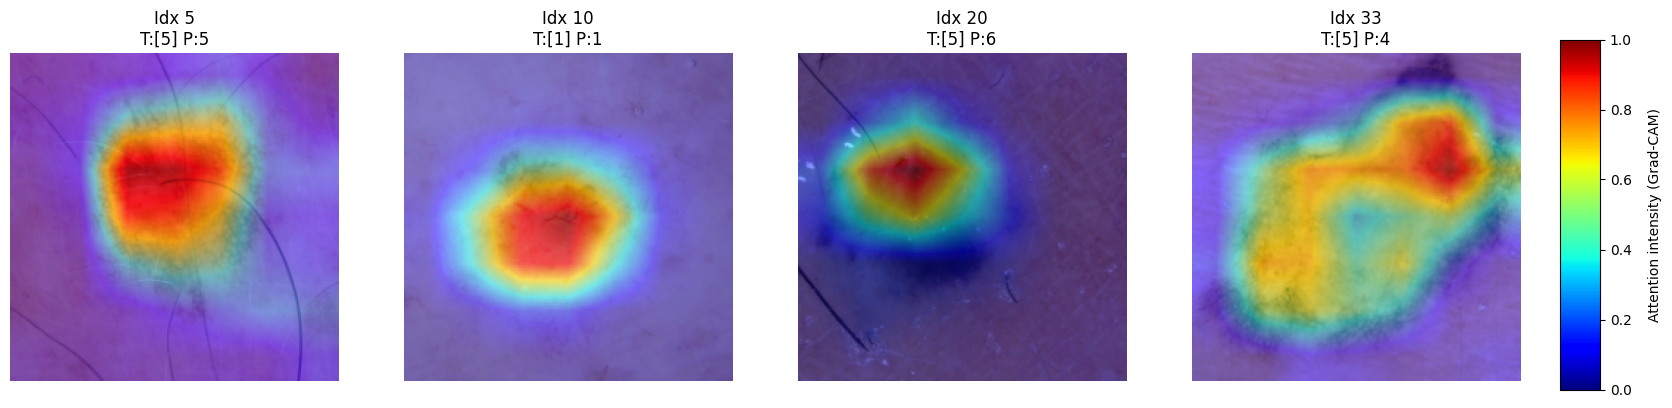

In [23]:
run_gradcam_grid(efficientnet_b0_cbam, test_dataset, [5, 10, 20, 33])

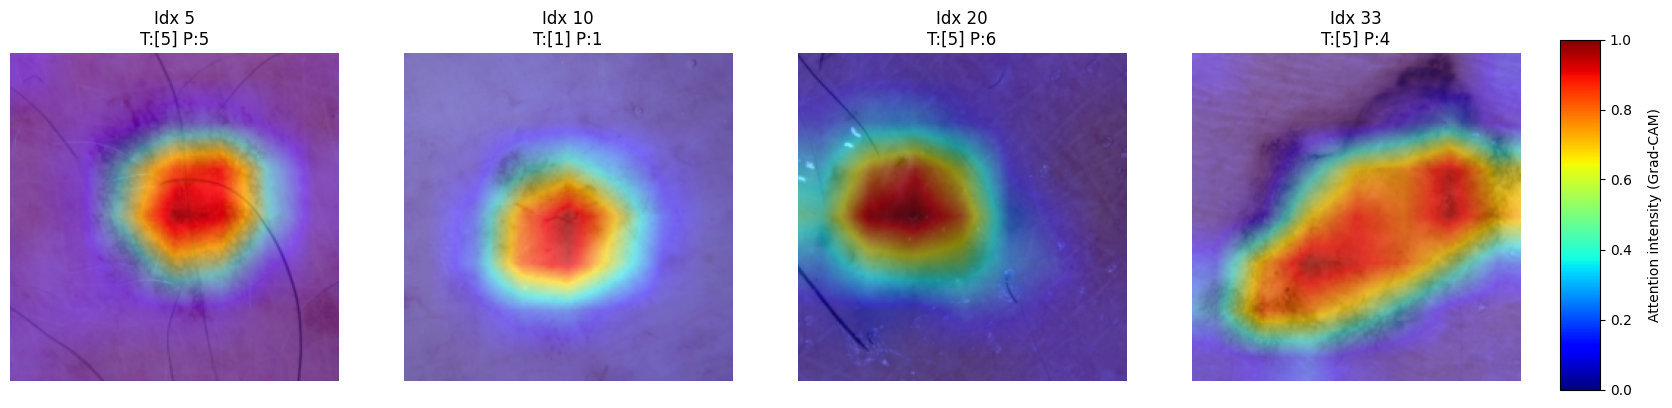

In [24]:
run_gradcam_grid(efficientnet_b1_cbam, test_dataset, [5, 10, 20, 33])

In [25]:
from medimeta import MedIMeta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

import os
from collections import Counter, defaultdict

W0505 01:04:35.986000 68192 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [26]:
ext_dataset = MedIMeta("/Users/diana/Desktop/Life in Boston/Course/BMI 712/Group_project", "skinl_derm", "Diagnosis")
sample = ext_dataset[0]

print("Sample image shape:", sample[0].shape)
print("Sample label:", sample[1])
print("Dataset size:", len(ext_dataset))

Sample image shape: torch.Size([3, 224, 224])
Sample label: tensor(0)
Dataset size: 1011


In [27]:
ann = pd.read_csv("/Users/diana/Desktop/Life in Boston/Course/BMI 712/Group_project/skinl_derm/annotations.csv")
df = ann[["filepath","split","Diagnosis","Diagnosis grouped","diagnosis"]].copy()
df.head()

,filepath,split,Diagnosis,Diagnosis grouped,diagnosis
0,images/000000.tiff,train,basal cell carcinoma,basal cell carcinoma,basal cell carcinoma
1,images/000001.tiff,val,basal cell carcinoma,basal cell carcinoma,basal cell carcinoma
2,images/000002.tiff,train,basal cell carcinoma,basal cell carcinoma,basal cell carcinoma
3,images/000003.tiff,test,basal cell carcinoma,basal cell carcinoma,basal cell carcinoma
4,images/000004.tiff,train,basal cell carcinoma,basal cell carcinoma,basal cell carcinoma


In [28]:
summary_df = (df.groupby(["Diagnosis", "split"]).size().reset_index(name="count"))
summary_wide = summary_df.pivot(index="Diagnosis", columns="split", values="count").fillna(0)
summary_wide["total"] = summary_wide.sum(axis=1)
summary_wide = summary_wide.reset_index()
summary_wide["proportion"] = summary_wide["total"] / summary_wide["total"].sum()
summary_wide

split,Diagnosis,test,train,val,total,proportion
0,basal cell carcinoma,16,19,7,42,0.041543
1,blue nevus,11,14,3,28,0.027695
2,clark nevus,156,176,67,399,0.394659
3,combined nevus,5,5,3,13,0.012859
4,congenital nevus,4,11,2,17,0.016815
5,dermal nevus,8,19,6,33,0.032641
6,dermatofibroma,7,6,7,20,0.019782
7,lentigo,12,7,5,24,0.023739
8,melanoma,101,90,61,252,0.249258
9,melanosis,6,7,3,16,0.015826


In [29]:
collapse_map = {
    "basal cell carcinoma": "basal cell carcinoma",
    "blue nevus": "melanocytic nevi",
    "clark nevus": "melanocytic nevi",
    "combined nevus": "melanocytic nevi",
    "congenital nevus": "melanocytic nevi",
    "dermal nevus": "melanocytic nevi",
    "recurrent nevus": "melanocytic nevi",
    "reed or spitz nevus": "melanocytic nevi",
    "dermatofibroma": "dermatofibroma",
    "lentigo": "benign keratosis-like lesions",
    "seborrheic keratosis": "benign keratosis-like lesions",
    "melanoma": "melanoma",
    "vascular lesion": "vascular lesions",

    "melanosis": np.nan,
    "miscellaneous": np.nan
}
df["class"] = df["Diagnosis"].map(collapse_map)
df_external = df.dropna(subset=["class"]).copy()

In [30]:
sum_df_new = (df_external.groupby(["class", "split"]).size().reset_index(name="count"))
sum_df_new = sum_df_new.pivot(index="class", columns="split", values="count").fillna(0)
sum_df_new["total"] = sum_df_new.sum(axis=1)
sum_df_new = sum_df_new.reset_index()
sum_df_new["proportion"] = sum_df_new["total"] / sum_df_new["total"].sum()
sum_df_new

split,class,test,train,val,total,proportion
0,basal cell carcinoma,16,19,7,42,0.042553
1,benign keratosis-like lesions,31,23,15,69,0.069909
2,dermatofibroma,7,6,7,20,0.020263
3,melanocytic nevi,219,256,100,575,0.582573
4,melanoma,101,90,61,252,0.255319
5,vascular lesions,13,9,7,29,0.029382


In [31]:
shared_classes = [
    "basal cell carcinoma",
    "benign keratosis-like lesions",
    "dermatofibroma",
    "melanoma",
    "melanocytic nevi",
    "vascular lesions"
]
class_to_id = {c: i for i, c in enumerate(shared_classes)}
df_external["class_id"] = df_external["class"].map(class_to_id)
print(class_to_id)

{'basal cell carcinoma': 0, 'benign keratosis-like lesions': 1, 'dermatofibroma': 2, 'melanoma': 3, 'melanocytic nevi': 4, 'vascular lesions': 5}


In [32]:
info = INFO["dermamnist"]
medmnist_labels = {
    k: int(v) for v, k in info["label"].items()
}

print(medmnist_labels)

{'actinic keratoses and intraepithelial carcinoma': 0, 'basal cell carcinoma': 1, 'benign keratosis-like lesions': 2, 'dermatofibroma': 3, 'melanoma': 4, 'melanocytic nevi': 5, 'vascular lesions': 6}


In [33]:
medmnist_to_medimeta = {}
for label, medmnist_id in medmnist_labels.items():
    if label in class_to_id:
        medmnist_to_medimeta[medmnist_id] = class_to_id[label]

print(medmnist_to_medimeta)

{1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}


In [34]:
X_list = []
y_list = []

for idx in df_external.index:
    x, _ = ext_dataset[idx]

    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    else:
        x = np.array(x)

    X_list.append(x)
    y_list.append(df_external.loc[idx, "class_id"])

X_ext = np.stack(X_list)
y_ext = np.array(y_list)

print("Full filtered X shape:", X_ext.shape)
print("Full filtered y shape:", y_ext.shape)

Full filtered X shape: (987, 3, 224, 224)
Full filtered y shape: (987,)


In [35]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np

class ExternalSkinDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]
        label = self.y[idx]

        if img.shape[0] == 3:
            img = np.transpose(img, (1, 2, 0))

        img = Image.fromarray(img.astype(np.uint8))

        if self.transform:
            img = self.transform(img)

        return img, label

external_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

external_dataset = ExternalSkinDataset(
    X_ext,
    y_ext,
    transform=external_transform
)

external_loader = DataLoader(
    external_dataset,
    batch_size=32,
    shuffle=False
)

In [36]:
import numpy as np
import torch

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

def evaluate_external_full(model, loader, class_names):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)         
            outputs = outputs[:, 1:]         

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    print(f"\nExternal Accuracy: {acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    ))

   
    n_classes = len(class_names)
    y_true_bin = label_binarize(
        all_labels,
        classes=list(range(n_classes))
    )
    macro_auc = roc_auc_score(
        y_true_bin,
        all_probs,
        average="macro",
        multi_class="ovr"
    )
    print(f"\nExternal AUC: {macro_auc:.4f}")

    return {
        "accuracy": acc,
        "macro_auc": macro_auc,
        "y_true": all_labels,
        "y_pred": all_preds
    }

In [37]:
results = evaluate_external_full(
    model=effnet_b0,          
    loader=external_loader,
    class_names=shared_classes
)


External Accuracy: 0.4276

Classification Report:
                               precision    recall  f1-score   support

         basal cell carcinoma       0.00      0.00      0.00        42
benign keratosis-like lesions       0.00      0.00      0.00        69
               dermatofibroma       0.00      0.00      0.00        20
                     melanoma       0.00      0.00      0.00       252
             melanocytic nevi       0.59      0.73      0.65       575
             vascular lesions       0.02      0.17      0.03        29

                     accuracy                           0.43       987
                    macro avg       0.10      0.15      0.11       987
                 weighted avg       0.34      0.43      0.38       987


External AUC: 0.4567


/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [38]:
results = evaluate_external_full(
    model=efficientnet_b0_cbam,          
    loader=external_loader,
    class_names=shared_classes
)


External Accuracy: 0.1854

Classification Report:
                               precision    recall  f1-score   support

         basal cell carcinoma       0.00      0.00      0.00        42
benign keratosis-like lesions       0.50      0.01      0.03        69
               dermatofibroma       0.00      0.00      0.00        20
                     melanoma       0.00      0.00      0.00       252
             melanocytic nevi       0.68      0.27      0.39       575
             vascular lesions       0.03      0.86      0.06        29

                     accuracy                           0.19       987
                    macro avg       0.20      0.19      0.08       987
                 weighted avg       0.43      0.19      0.23       987


External AUC: 0.5467


/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [43]:
results = evaluate_external_full(
    model=effnet_b1,          
    loader=external_loader,
    class_names=shared_classes
)


External Accuracy: 0.5795

Classification Report:
                               precision    recall  f1-score   support

         basal cell carcinoma       0.00      0.00      0.00        42
benign keratosis-like lesions       0.00      0.00      0.00        69
               dermatofibroma       0.00      0.00      0.00        20
                     melanoma       0.00      0.00      0.00       252
             melanocytic nevi       0.58      0.99      0.73       575
             vascular lesions       0.00      0.00      0.00        29

                     accuracy                           0.58       987
                    macro avg       0.10      0.17      0.12       987
                 weighted avg       0.34      0.58      0.43       987


External AUC: 0.4871


/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [40]:
results = evaluate_external_full(
    model=efficientnet_b1_cbam,          
    loader=external_loader,
    class_names=shared_classes
)


External Accuracy: 0.0446

Classification Report:
                               precision    recall  f1-score   support

         basal cell carcinoma       0.00      0.00      0.00        42
benign keratosis-like lesions       0.00      0.00      0.00        69
               dermatofibroma       0.05      0.05      0.05        20
                     melanoma       0.00      0.00      0.00       252
             melanocytic nevi       0.78      0.02      0.05       575
             vascular lesions       0.03      1.00      0.06        29

                     accuracy                           0.04       987
                    macro avg       0.14      0.18      0.03       987
                 weighted avg       0.45      0.04      0.03       987


External AUC: 0.5482


/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result